# Разработка A/B-тестирования и анализ результатов

В развлекательном приложении с бесконечной лентой контента (аналог short-video feed) используются две модели монетизации: платная подписка без рекламы и рекламная модель для пользователей без подписки. Качество рекомендательного алгоритма напрямую влияет на вовлечённость пользователей, глубину просмотра и, как следствие, на рекламные доходы и конверсию в подписку.

Команда рекомендательных систем разработала новый алгоритм персонализации контента. Для оценки его эффективности необходимо спроектировать и провести A/B-эксперимент: определить ключевые и барьерные метрики, рассчитать параметры теста (уровень значимости, мощность, минимально детектируемый эффект и объём выборки), проверить корректность рандомизации и качества данных, а затем проанализировать результаты эксперимента и сформулировать продуктовую рекомендацию по внедрению алгоритма.

## Описание данных

Для проведения анализа использовались три набора данных:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Необходимо рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
# Считаем количество уникальных сессий на пользователя
sessions_per_user = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
)

# Находим пользователя с максимальным числом сессий
top_user = sessions_per_user.idxmax()

# Выводим все данные по этому пользователю
sessions_history[sessions_history['user_id'] == top_user]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Посчитаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.


In [3]:
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

daily_stats = (
    sessions_history
    .groupby('session_date')
    .agg(
        users_cnt=('user_id', 'nunique'),
        registered_users_cnt=('registration_flag', 'sum')  # по условию 0/1 и в рамках дня не меняется
    )
    .reset_index()
)

daily_stats['registered_share'] = daily_stats['registered_users_cnt'] / daily_stats['users_cnt']

daily_stats.head()

,session_date,users_cnt,registered_users_cnt,registered_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


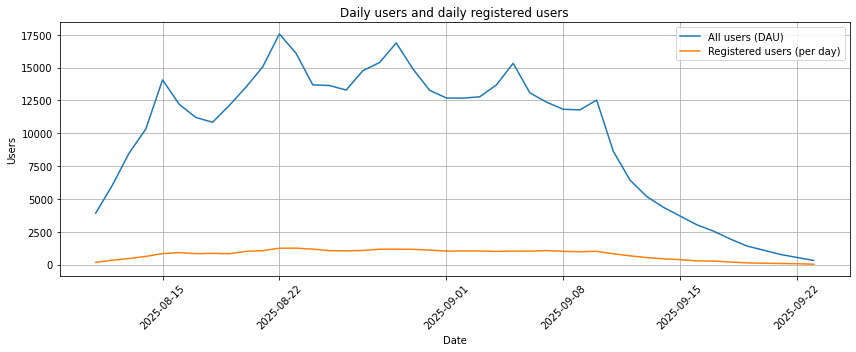

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['users_cnt'], label='All users (DAU)')
plt.plot(daily_stats['session_date'], daily_stats['registered_users_cnt'], label='Registered users (per day)')

plt.title('Daily users and daily registered users')
plt.xlabel('Date')
plt.ylabel('Users')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

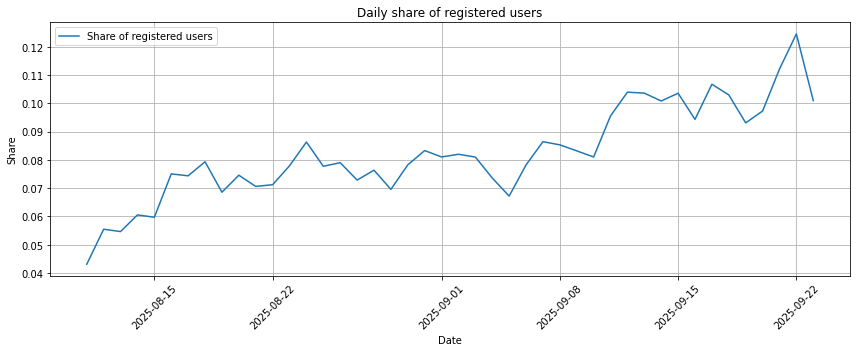

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'], label='Share of registered users')

plt.title('Daily share of registered users')
plt.xlabel('Date')
plt.ylabel('Share')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По результатам анализа исторических данных наблюдается рост общего числа активных пользователей в первые недели периода с последующим снижением к концу наблюдаемого интервала. Количество зарегистрированных пользователей по дням изменяется пропорционально общему числу пользователей. 

Доля зарегистрированных пользователей постепенно увеличивается со временем: если в начале периода она составляла около 4–6%, то к концу достигала значений выше 10%. Это может свидетельствовать об улучшении конверсии в регистрацию или изменении структуры трафика. В целом динамика регистраций повторяет динамику общего трафика приложения, без резких аномалий или выбросов.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [6]:
# выбираем только первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# считаем, сколько первых сессий приходится на каждое значение page_counter
pages_distribution = (
    first_sessions
    .groupby('page_counter')['session_id']
    .count()
    .reset_index()
    .rename(columns={'session_id': 'sessions_count'})
    .sort_values(by='page_counter')
)

pages_distribution.head()

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075


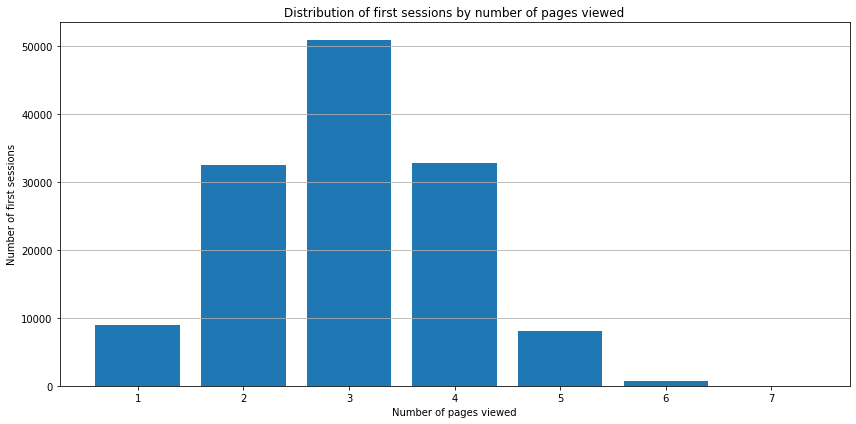

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(pages_distribution['page_counter'], pages_distribution['sessions_count'])

plt.title('Distribution of first sessions by number of pages viewed')
plt.xlabel('Number of pages viewed')
plt.ylabel('Number of first sessions')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

По результатам анализа первых сессий пользователей видно, что наибольшее количество сессий приходится на 2–4 просмотренные страницы. Максимум распределения наблюдается при 3 страницах (более 50 тысяч первых сессий), далее частота постепенно снижается. Сессии с 1 просмотренной страницей встречаются существенно реже, чем с 2–4 страницами, что может свидетельствовать о достаточно высоком уровне первоначальной вовлечённости пользователей.

После 4 страниц количество первых сессий резко уменьшается: при 5 страницах их уже значительно меньше, а при 6 и более — доля становится минимальной. Это говорит о том, что большинство пользователей в первую сессию просматривают ограниченное число страниц, и только небольшая часть демонстрирует более глубокое взаимодействие с контентом.

В целом распределение носит правосторонний характер с пиком в диапазоне 2–4 страниц, что подтверждает гипотезу о том, что глубина просмотра может служить индикатором вовлечённости пользователя на раннем этапе взаимодействия с приложением.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

In [8]:
# создаём столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# берём только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# считаем среднюю долю успешных первых сессий по дням
daily_good_share = (
    first_sessions
    .groupby('session_date')['good_session']
    .mean()
    .reset_index()
)

daily_good_share.head()

,session_date,good_session
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114


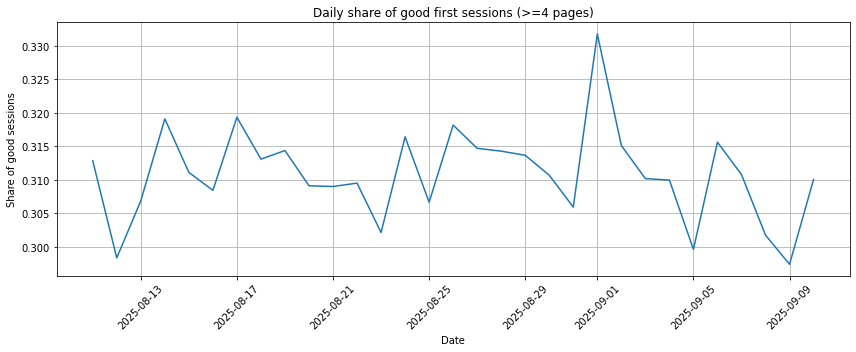

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(daily_good_share['session_date'], daily_good_share['good_session'])

plt.title('Daily share of good first sessions (>=4 pages)')
plt.xlabel('Date')
plt.ylabel('Share of good sessions')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По результатам анализа видно, что доля «успешных» первых сессий (сессий с 4 и более просмотренными страницами) на протяжении всего периода наблюдения колеблется в диапазоне примерно 30–33%. Существенных резких скачков или аномалий не наблюдается, динамика показателя выглядит относительно стабильной.

Небольшие колебания доли успешных сессий по дням могут быть связаны с естественной вариативностью трафика или изменением структуры пользователей, однако общий уровень вовлечённости остаётся примерно постоянным. Это позволяет использовать данный показатель в дальнейшем как устойчивую прокси-метрику для оценки влияния изменений в продукте, в частности нового алгоритма рекомендаций.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Для корректного проведения эксперимента необходимо заранее определить требуемый размер выборки. Он рассчитывается на основе выбранного уровня значимости, мощности теста и минимально детектируемого эффекта (MDE).

В данном проекте расчёт выполняется программно с использованием статистических методов, что позволяет обеспечить воспроизводимость и прозрачность оценки требуемого объёма пользователей для каждой экспериментальной группы.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

При расчёте размера выборки будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# параметры
alpha = 0.05
beta = 0.2
power = 1 - beta

p1 = 0.3

# MDE как 3% от базового уровня p (относительное изменение)
mde = p1 * 0.03  # 0.009

# размер эффекта
effect_size = proportion_effectsize(p1, p1 + mde)

# инициализация класса
power_analysis = NormalIndPower()

# расчёт размера выборки (ВАЖНО: effect_size=effect_size, а не mde)
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [11]:
from math import ceil

# среднее число уникальных пользователей в день
avg_daily_users = (
    sessions_history
    .groupby('session_date')['user_id']
    .nunique()
    .mean()
)

# длительность теста (в днях)
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(
    f"Рассчитанная длительность A/B-теста при текущем уровне трафика "
    f"в {int(avg_daily_users)} пользователей в день составит {test_duration} дней"
)

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Посчитаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [12]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

sessions_test_part['session_date'] = pd.to_datetime(sessions_test_part['session_date'])

day = sessions_test_part['session_date'].min()

users_by_group = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='users_cnt')
)

a_users = users_by_group.loc[users_by_group['test_group'] == 'A', 'users_cnt'].iloc[0]
b_users = users_by_group.loc[users_by_group['test_group'] == 'B', 'users_cnt'].iloc[0]

p_diff = 100 * abs(a_users - b_users) / a_users

print(f"Дата наблюдения: {day.date()}")
print(users_by_group)
print(f"Процентная разница между группами A и B: {p_diff:.2f}%")

Дата наблюдения: 2025-10-14
  test_group  users_cnt
0          A       1477
1          B       1466
Процентная разница между группами A и B: 0.74%


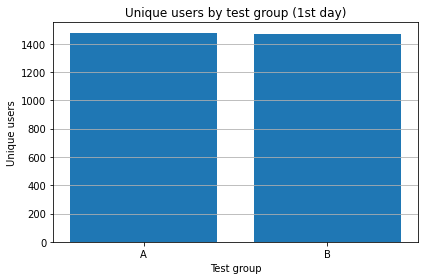

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(users_by_group['test_group'], users_by_group['users_cnt'])
plt.title('Unique users by test group (1st day)')
plt.xlabel('Test group')
plt.ylabel('Unique users')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B.

In [14]:
# получаем множества пользователей по группам
users_A = set(
    sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
)

users_B = set(
    sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
)

# ищем пересечение
intersection_users = users_A & users_B

print(f"Количество пользователей, попавших одновременно в A и B: {len(intersection_users)}")

Количество пользователей, попавших одновременно в A и B: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [15]:
# считаем доли типов устройств в каждой группе
device_share = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .reset_index()
)

# считаем общее число пользователей в каждой группе
group_totals = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='total_users')
)

# объединяем
device_share = device_share.merge(group_totals, on='test_group')

# считаем долю
device_share['share'] = device_share['user_id'] / device_share['total_users']

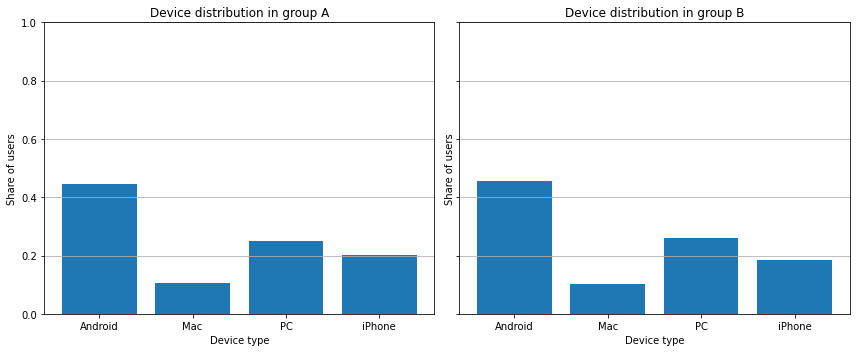

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, group in enumerate(['A', 'B']):
    data = device_share[device_share['test_group'] == group]
    
    axes[i].bar(data['device'], data['share'])
    axes[i].set_title(f'Device distribution in group {group}')
    axes[i].set_xlabel('Device type')
    axes[i].set_ylabel('Share of users')
    axes[i].grid(axis='y')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Также необходимо убедиться, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.


In [17]:
# считаем доли регионов в каждой группе
region_share = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .reset_index()
)

# считаем общее число пользователей в группах
group_totals = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='total_users')
)

# объединяем
region_share = region_share.merge(group_totals, on='test_group')

# считаем долю
region_share['share'] = region_share['user_id'] / region_share['total_users']

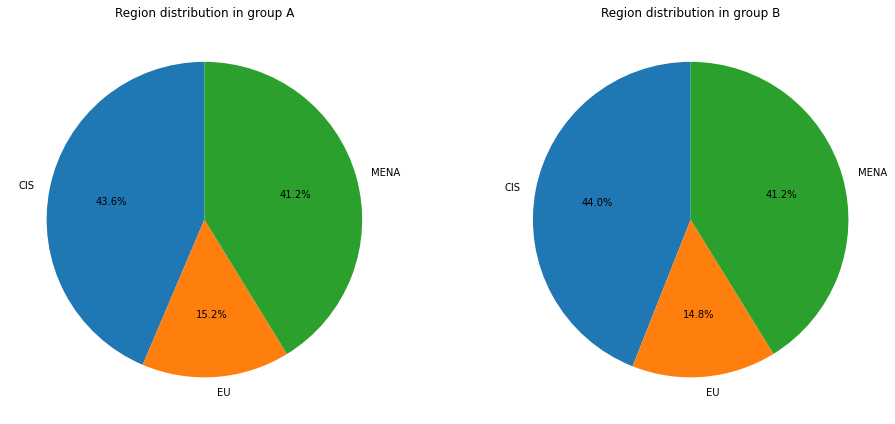

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, group in enumerate(['A', 'B']):
    data = region_share[region_share['test_group'] == group]
    
    axes[i].pie(
        data['share'],
        labels=data['region'],
        autopct='%1.1f%%',
        startangle=90
    )
    
    axes[i].set_title(f'Region distribution in group {group}')

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

По результатам мониторинга A/B-теста за первый день наблюдения можно сделать вывод, что эксперимент запущен корректно и проходит без нарушений. Количество пользователей в группах практически одинаково: в группе A — 1477 человек, в группе B — 1466 человек, процентная разница составляет всего 0.74%, что говорит об отсутствии существенного перекоса в объёмах выборок. 

Пересечения пользователей между группами не обнаружено (0 пользователей попали одновременно в A и B), следовательно, группы являются независимыми и рандомизация реализована корректно.

Анализ распределения по типам устройств показал практически совпадающие доли пользователей в обеих группах (Android около 45%, Mac около 10%, PC около 25–26%, iPhone около 19–20%), что свидетельствует об отсутствии дисбаланса по данной категориальной переменной. 

Аналогичная ситуация наблюдается и по регионам: доли пользователей из CIS, EU и MENA в группах A и B практически идентичны, различия находятся в пределах статистической погрешности. 

Таким образом, существенных нарушений дизайна эксперимента не выявлено, распределение пользователей является равномерным, группы независимы, и A/B-тест на текущем этапе проходит корректно и может быть продолжен.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Посчитаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [19]:
# загружаем полный датасет теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# создаём столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

В рамках данного A/B-теста проверяется гипотеза о том, что новый алгоритм рекомендаций показывает пользователям более релевантный и интересный контент. В качестве основной метрики выбрана доля «успешных» сессий, в которых пользователь просмотрел 4 и более страниц (good_session). Эта метрика отражает вовлечённость пользователя и используется как прокси-показатель качества рекомендаций.

Нулевая гипотеза 𝐻0: доля успешных сессий в группе с новым алгоритмом (группа B) не отличается от доли успешных сессий в контрольной группе (группа A), то есть новый алгоритм не влияет на вовлечённость пользователей.

Альтернативная гипотеза 𝐻1: доля успешных сессий в группе B выше, чем в группе A, то есть новый алгоритм повышает вовлечённость пользователей.

Целевой метрикой является доля успешных сессий (good_session). В качестве прокси-метрики можно использовать среднее количество просмотренных страниц за сессию, поскольку оно также отражает вовлечённость. В качестве барьерных (guardrail) метрик при самостоятельном проведении эксперимента стоило бы отслеживать показатели, которые могут ухудшиться при внедрении нового алгоритма: например, среднюю длительность сессии, частоту отказов (сессии с 1 просмотренной страницей), технические метрики (ошибки, время загрузки), а также ключевые бизнес-метрики — конверсию в регистрацию и подписку. Это позволило бы убедиться, что улучшение основной метрики не приводит к негативным побочным эффектам.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [20]:
# Доля успешных первых сессий по группам A и B

first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

good_share = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .mean()
    .reset_index(name='good_share')
)

share_A = good_share.loc[good_share['test_group'] == 'A', 'good_share'].iloc[0]
share_B = good_share.loc[good_share['test_group'] == 'B', 'good_share'].iloc[0]

diff = share_B - share_A

print("Доля успешных первых сессий:")
print(good_share)
print(f"\nРазница (B - A): {diff:.4f}")

Доля успешных первых сессий:
  test_group  good_share
0          A    0.315724
1          B    0.314673

Разница (B - A): -0.0011


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости. Уровень значимости в эксперименте был выбран на уровне 0.05.

In [21]:
from statsmodels.stats.proportion import proportions_ztest

# берем только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# считаем количество успехов и наблюдений в каждой группе
group_stats = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .agg(['sum', 'count'])
)

success_A = group_stats.loc['A', 'sum']
n_A = group_stats.loc['A', 'count']

success_B = group_stats.loc['B', 'sum']
n_B = group_stats.loc['B', 'count']

successes = [success_A, success_B]
nobs = [n_A, n_B]

# односторонний z-test: H1 (B > A)
stat, p_value = proportions_ztest(successes, nobs, alternative='smaller')

print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Различие статистически значимо: доля успешных первых сессий в группе B выше, чем в группе A.")
else:
    print("Статистически значимого улучшения в группе B по сравнению с A не обнаружено.")

p-value: 0.57835
Статистически значимого улучшения в группе B по сравнению с A не обнаружено.


#### 4.5. Вывод по результатам A/B-эксперимента


В рамках эксперимента тестировалось влияние нового алгоритма рекомендаций на ключевую метрику — долю успешных первых сессий (сессий с 4 и более просмотренными страницами). Перед запуском теста был рассчитан необходимый размер выборки при уровне значимости 0.05, мощности 0.8 и минимальном детектируемом эффекте 3% от базового уровня. Требуемый размер выборки составил 41040 пользователей на каждую группу. При среднем дневном трафике около 9907 уникальных пользователей расчётная длительность эксперимента составила 9 дней.

Мониторинг показал корректность проведения эксперимента: распределение пользователей между группами было равномерным (процентная разница менее 1%), пересечений пользователей между группами не выявлено, распределение по устройствам и регионам сохранялось сбалансированным. Это подтверждает независимость выборок и корректность рандомизации.

По итогам анализа доля успешных первых сессий в контрольной группе составила 31.57%, а в тестовой группе — 31.47%. Разница (B − A) составила −0.11 процентного пункта, то есть улучшения в тестовой группе не наблюдается.

Для проверки статистической значимости различий был проведён односторонний z-тест (проверялась гипотеза о том, что группа B лучше группы A). Полученное значение p-value = 0.57835, что значительно выше уровня значимости 0.05. Следовательно, нулевая гипотеза не отвергается, статистически значимого улучшения в группе B по сравнению с группой A не обнаружено.

Таким образом, новый алгоритм рекомендаций не продемонстрировал статистически значимого роста ключевой метрики. На основании полученных результатов внедрение алгоритма в текущем виде не рекомендуется.